# TRACE — Exploratory Data Analysis (EDA)

## Purpose
This notebook explores the IEEE-CIS transaction data before model building.

The analysis covers data inspection, univariate and bivariate analysis, missingness, temporal behavior, entity relationships, and multivariate patterns.

> **Important Note:** This notebook is for understanding the dataset and discovering useful patterns. The analysis here should inform later feature engineering and modeling, not replace the validation process.

In [1]:
import sys
from pathlib import Path

import pandas as pd
PROJECT_ROOT = Path.cwd().parents[1]
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

In [2]:
from pathlib import Path

print(Path.cwd())

C:\Users\Manojit Khatua\AI ENGINEERING\trace-ai\src\analysis


## 1. Data Loading & Initial Inspection

In [3]:
from analysis_src.data_inspection import (DataInspector,ViewOfDataStrategy,DataTypesInspectionStrategy,SummaryStatisticalInspectionStrategy,)
from analysis_src.univariate_analysis import (UnivariateAnalyzer,FraudDistributionStrategy,NumericalDistributionStrategy,CategoricalDistributionStrategy,)
from analysis_src.bivariate_analysis import (BivariateAnalyzer,NumericalVsFraudStrategy,CategoricalVsFraudStrategy,TemporalVsFraudStrategy,)
from analysis_src.missing_value_analysis import (MissingValueAnalyzer,MissingPercentageStrategy,MissingnessVsFraudStrategy,)
from analysis_src.temporal_analysis import (TemporalAnalyzer,FraudRateByTimeBinStrategy,TransactionVolumeByTimeBinStrategy,FraudCountByTimeBinStrategy,TransactionVelocityStrategy,InterTransactionTimeStrategy,)
from analysis_src.entity_analysis import (EntityAnalyzer,EntityCardinalityStrategy,SharedEntityStrategy,EntityFraudRateStrategy,)
from analysis_src.relationship_analysis import (RelationshipAnalyzer,EntityPairFrequencyStrategy,EntityPairFraudRateStrategy,)
from analysis_src.multivariate_analysis import (MultivariateAnalyzer,CorrelationAnalysisStrategy,TargetGroupComparisonStrategy)
from analysis_src.entity_analysis import (EntityAnalyzer,DeviceCardConnectivityStrategy)

In [4]:
import pandas as pd
train_transaction = pd.read_csv("../data/processed/extracted_data/train_transaction.csv")
train_identity = pd.read_csv("../data/processed/extracted_data/train_identity.csv")
print("Train Transaction Shape:", train_transaction.shape)
print("Train Identity Shape:", train_identity.shape)

Train Transaction Shape: (590540, 394)
Train Identity Shape: (144233, 41)


In [5]:
inspector = DataInspector(DataTypesInspectionStrategy())
inspector.execute_inspection(train_transaction)


Data types and non-null information:
<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), str(14)
memory usage: 1.7 GB


In [6]:
# Summary Statistic 
inspector.execute_inspection(train_identity)
inspector.set_strategy(SummaryStatisticalInspectionStrategy())
print("/n Train_transaction staistic")
inspector.execute_inspection(train_transaction)
print("/n Test_transaction statistic")
inspector.execute_inspection(train_identity)


Data types and non-null information:
<class 'pandas.DataFrame'>
RangeIndex: 144233 entries, 0 to 144232
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionID  144233 non-null  int64  
 1   id_01          144233 non-null  float64
 2   id_02          140872 non-null  float64
 3   id_03          66324 non-null   float64
 4   id_04          66324 non-null   float64
 5   id_05          136865 non-null  float64
 6   id_06          136865 non-null  float64
 7   id_07          5155 non-null    float64
 8   id_08          5155 non-null    float64
 9   id_09          74926 non-null   float64
 10  id_10          74926 non-null   float64
 11  id_11          140978 non-null  float64
 12  id_12          144233 non-null  str    
 13  id_13          127320 non-null  float64
 14  id_14          80044 non-null   float64
 15  id_15          140985 non-null  str    
 16  id_16          129340 non-null  str    
 17  id

Basic Data Inspection
---------------------

The basic inspection was performed to understand the structure of the
IEEE-CIS transaction data before carrying out deeper analysis.

The inspection examined:
- Dataset shape
- Available columns
- Data types
- Non-null and missing values
- Numerical summary statistics
- Categorical summary statistics

The training transaction dataset contains 590,540 transactions.
The fraud target is highly imbalanced, with approximately 3.5% fraudulent
transactions.

The inspection also revealed that several feature groups, especially
V-series and D-series variables, contain substantial missing values.

These observations were used to decide which variables and patterns
required deeper EDA.


## 2. Univariate Analysis


Fraud Distribution:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud Distribution (%):
isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


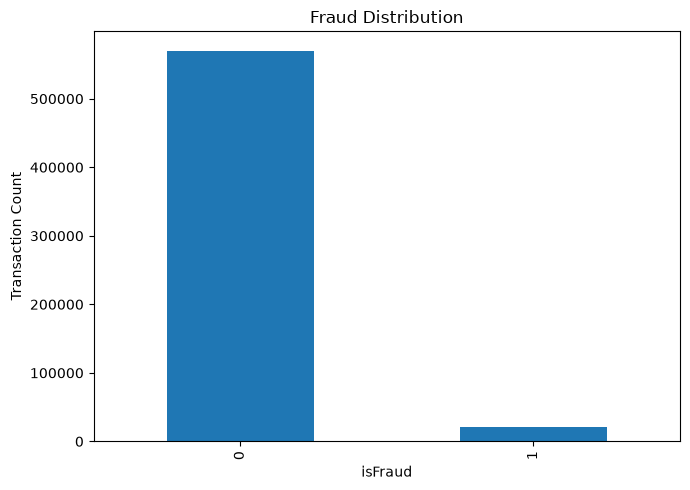


Summary for TransactionAmt:
count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64


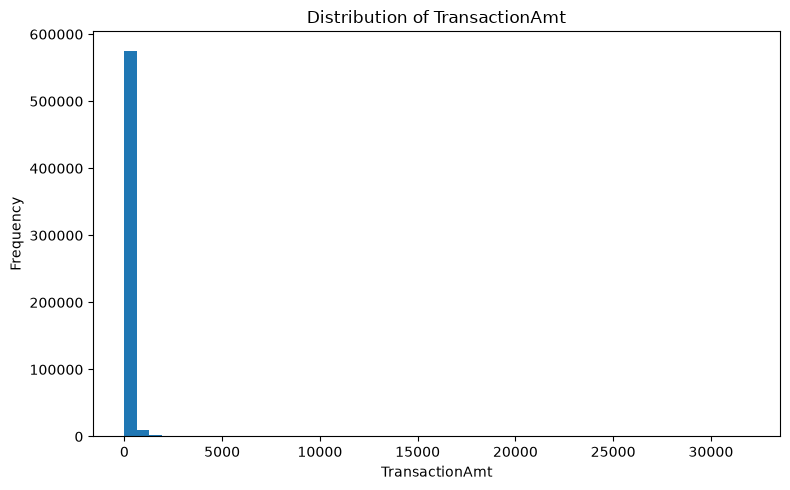


Summary for TransactionDT:
count    5.905400e+05
mean     7.372311e+06
std      4.617224e+06
min      8.640000e+04
25%      3.027058e+06
50%      7.306528e+06
75%      1.124662e+07
max      1.581113e+07
Name: TransactionDT, dtype: float64


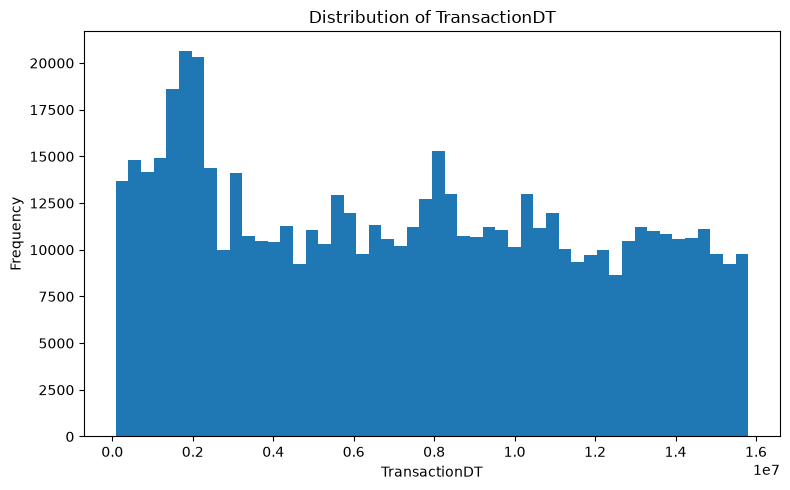


Top values for ProductCD:
ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64


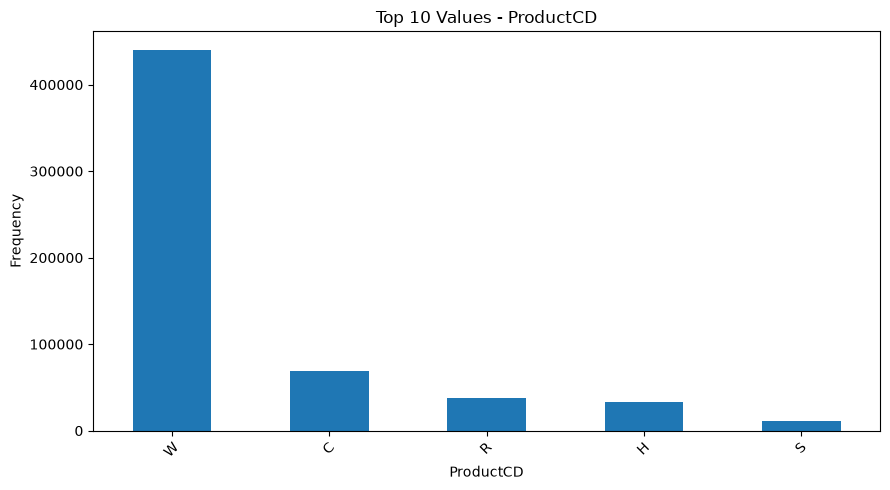


Top values for card4:
card4
visa                384767
mastercard          189217
american express      8328
discover              6651
NaN                   1577
Name: count, dtype: int64


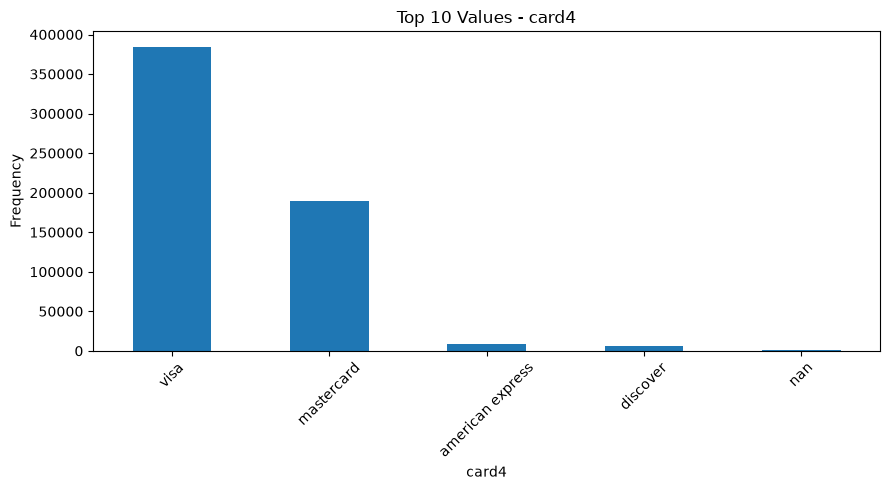


Top values for card6:
card6
debit              439938
credit             148986
NaN                  1571
debit or credit        30
charge card            15
Name: count, dtype: int64


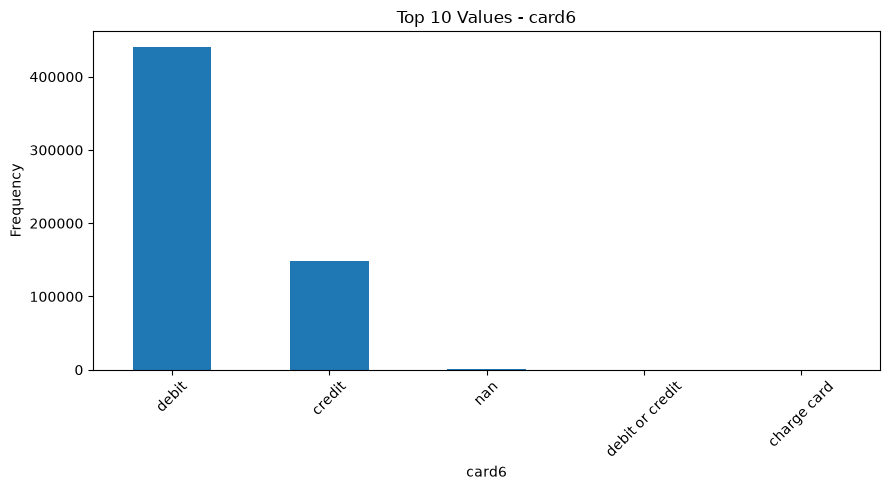

card6
debit              439938
credit             148986
NaN                  1571
debit or credit        30
charge card            15
Name: count, dtype: int64

In [7]:
# Univaraite Analysis
analyzer = UnivariateAnalyzer(FraudDistributionStrategy())
fraud_distribution = analyzer.execute_analysis(train_transaction)
analyzer.set_strategy(NumericalDistributionStrategy("TransactionAmt"))
analyzer.execute_analysis(train_transaction)
analyzer.set_strategy(NumericalDistributionStrategy("TransactionDT"))
analyzer.execute_analysis(train_transaction)
analyzer.set_strategy(CategoricalDistributionStrategy("ProductCD"))
analyzer.execute_analysis(train_transaction)
analyzer.set_strategy(CategoricalDistributionStrategy("card4"))
analyzer.execute_analysis(train_transaction)
analyzer.set_strategy(CategoricalDistributionStrategy("card6"))
analyzer.execute_analysis(train_transaction)

Univariate Analysis
-------------------

Univariate analysis was used to understand the individual distribution
of important variables without considering relationships between variables.

The analysis examined:
- Fraud distribution
- Transaction amount distribution
- Transaction time distribution
- Product category distribution
- Card type distributions

The fraud distribution showed:
- Legitimate transactions: 569,877
- Fraudulent transactions: 20,663
- Overall fraud rate: approximately 3.5%

TransactionAmt was strongly right-skewed. Most transactions were concentrated
at relatively low values, while a small number of transactions had very
large amounts.

TransactionDT was distributed across a broad time range, indicating that
transaction activity varies throughout the dataset timeline.

ProductCD, card4 and card6 showed highly uneven category frequencies.

## 3. Bivariate Analysis


TransactionAmt by Fraud Status:
            count        mean         std    min     25%   50%    75%  \
isFraud                                                                 
0        569877.0  134.511665  239.395078  0.251  43.970  68.5  120.0   
1         20663.0  149.244779  232.212163  0.292  35.044  75.0  161.0   

               max  
isFraud             
0        31937.391  
1         5191.000  


<Figure size 800x500 with 0 Axes>

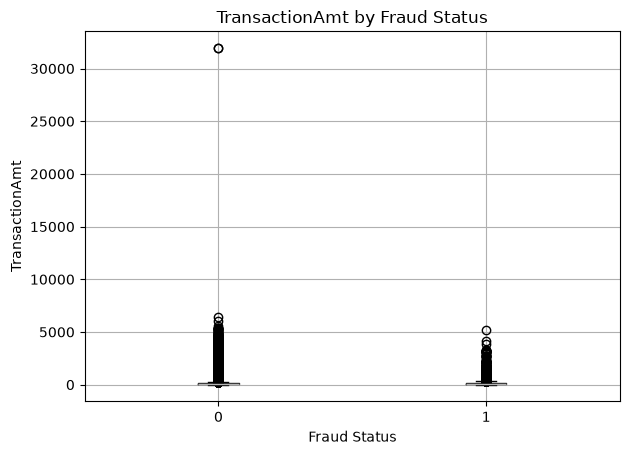


Fraud Rate Across Transaction Time:
time_bin
(70675.268, 872636.55]       0.028566
(872636.55, 1658873.1]       0.025281
(1658873.1, 2445109.65]      0.020303
(2445109.65, 3231346.2]      0.036935
(3231346.2, 4017582.75]      0.039457
(4017582.75, 4803819.3]      0.040913
(4803819.3, 5590055.85]      0.044521
(5590055.85, 6376292.4]      0.044219
(6376292.4, 7162528.95]      0.037063
(7162528.95, 7948765.5]      0.038455
(7948765.5, 8735002.05]      0.032038
(8735002.05, 9521238.6]      0.038688
(9521238.6, 10307475.15]     0.047765
(10307475.15, 11093711.7]    0.034937
(11093711.7, 11879948.25]    0.038403
(11879948.25, 12666184.8]    0.034359
(12666184.8, 13452421.35]    0.031675
(13452421.35, 14238657.9]    0.029522
(14238657.9, 15024894.45]    0.035229
(15024894.45, 15811131.0]    0.040480
Name: isFraud, dtype: float64


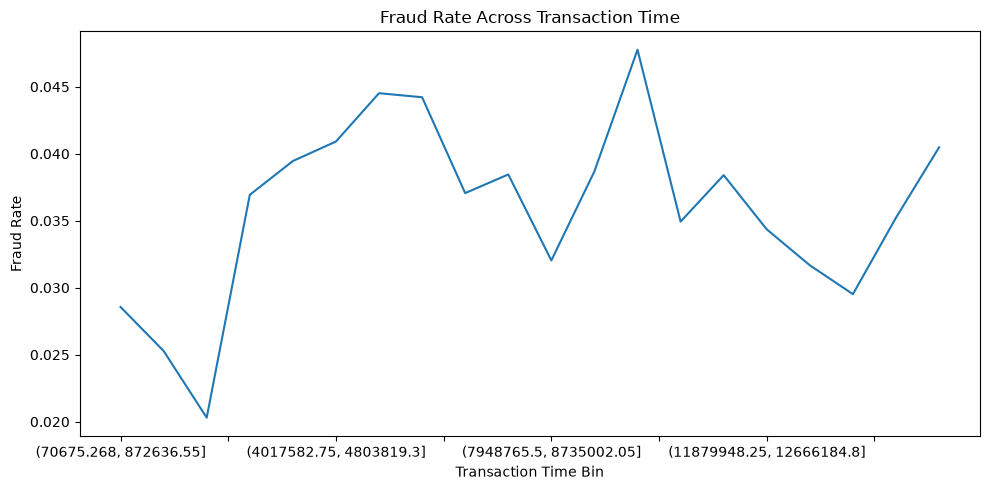


Fraud Rate by ProductCD:
           transaction_count  fraud_count  fraud_rate
ProductCD                                            
C                      68519         8008    0.116873
S                      11628          686    0.058996
H                      33024         1574    0.047662
R                      37699         1426    0.037826
W                     439670         8969    0.020399


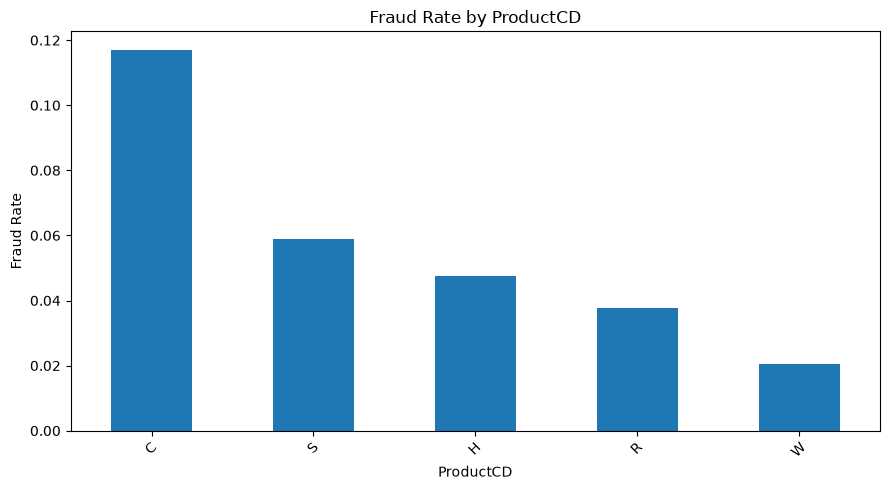


Fraud Rate by card6:
                 transaction_count  fraud_count  fraud_rate
card6                                                      
credit                      148986         9950    0.066785
NaN                           1571           39    0.024825
debit                       439938        10674    0.024263
charge card                     15            0    0.000000
debit or credit                 30            0    0.000000


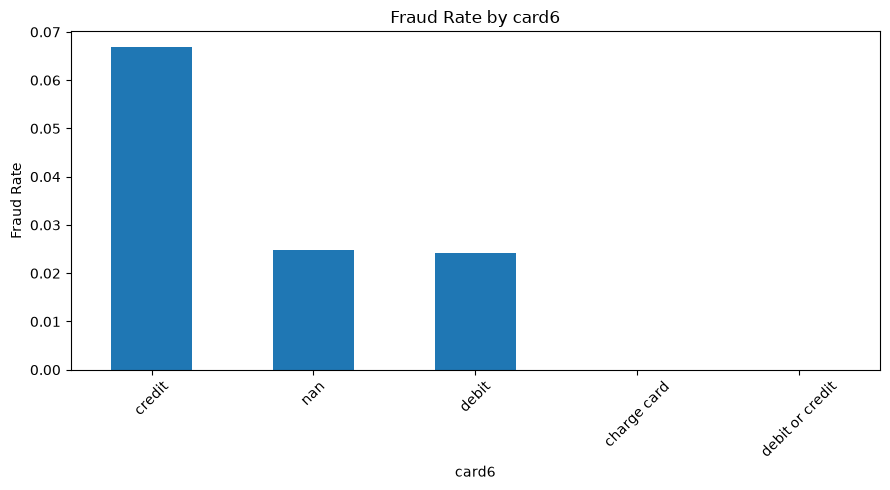

In [8]:
analyzer = BivariateAnalyzer(NumericalVsFraudStrategy("TransactionAmt"))
amount_vs_fraud = analyzer.execute_analysis(train_transaction)
analyzer.set_strategy(TemporalVsFraudStrategy())
time_vs_fraud = analyzer.execute_analysis(train_transaction)
analyzer.set_strategy(CategoricalVsFraudStrategy("ProductCD"))
product_vs_fraud = analyzer.execute_analysis(train_transaction)
analyzer.set_strategy(CategoricalVsFraudStrategy("card6"))
card6_vs_fraud = analyzer.execute_analysis(train_transaction)

# Bivariate Analysis
------------------

Bivariate analysis was used to investigate the relationship between
individual features and the fraud target.

The analysis examined:
- TransactionAmt vs isFraud
- TransactionDT vs isFraud
- ProductCD vs isFraud
- card6 vs isFraud

TransactionAmt showed some difference between legitimate and fraudulent
transactions, but the difference was not large enough to consider amount
as a standalone fraud signal.

Fraud rate varied across transaction-time bins, showing that fraud intensity
is not constant over the observed timeline.

ProductCD showed substantial differences in fraud rate:
- C: approximately 11.69%
- S: approximately 5.90%
- H: approximately 4.77%
- R: approximately 3.78%
- W: approximately 2.04%

card6 also showed a difference:
- Credit: approximately 6.68%
- Debit: approximately 2.42%

These results identified categorical and temporal variables as potentially
useful predictive signals.

## 4. Missing Value Analysis

In [9]:
# Missing value analysis
missing_analyzer = MissingValueAnalyzer(MissingPercentageStrategy())
missing_summary = (missing_analyzer.execute_analysis(train_transaction))
missing_summary.head(20)


Missing Value Analysis:
       missing_count  missing_percentage
dist2         552913           93.628374
D7            551623           93.409930
D13           528588           89.509263
D14           528353           89.469469
D12           525823           89.041047
...              ...                 ...
V302              12            0.002032
V303              12            0.002032
V304              12            0.002032
V305              12            0.002032
V306              12            0.002032

[374 rows x 2 columns]


,missing_count,missing_percentage
dist2,552913,93.628374
D7,551623,93.409930
D13,528588,89.509263
D14,528353,89.469469
D12,525823,89.041047
D6,517353,87.606767
D8,515614,87.312290
D9,515614,87.312290
V154,508595,86.123717
V153,508595,86.123717


In [10]:
missing_analyzer.set_strategy(MissingnessVsFraudStrategy())
missing_fraud = (missing_analyzer.execute_analysis(train_transaction))
missing_fraud.head(20)


Missingness vs Fraud Analysis:
Minimum missing observations: 1000
    feature  missing_count  missing_fraud_count  missing_fraud_rate  \
0        D7         551623                14873            0.026962   
1     addr1          65706                 7741            0.117813   
2     addr2          65706                 7741            0.117813   
3       D12         525823                13065            0.024847   
4       D14         528353                13450            0.025456   
..      ...            ...                  ...                 ...   
294    V296           1269                   46            0.036249   
295    V313           1269                   46            0.036249   
296    V301           1269                   46            0.036249   
297    V300           1269                   46            0.036249   
298    V314           1269                   46            0.036249   

     present_count  present_fraud_count  present_fraud_rate  \
0            3891

,feature,missing_count,missing_fraud_count,missing_fraud_rate,present_count,present_fraud_count,present_fraud_rate,fraud_rate_difference,absolute_difference
0,D7,551623,14873,0.026962,38917,5790,0.148778,-0.121816,0.121816
1,addr1,65706,7741,0.117813,524834,12922,0.024621,0.093192,0.093192
2,addr2,65706,7741,0.117813,524834,12922,0.024621,0.093192,0.093192
3,D12,525823,13065,0.024847,64717,7598,0.117403,-0.092557,0.092557
4,D14,528353,13450,0.025456,62187,7213,0.115989,-0.090532,0.090532
5,D13,528588,13826,0.026156,61952,6837,0.110360,-0.084203,0.084203
6,D6,517353,12945,0.025022,73187,7718,0.105456,-0.080434,0.080434
7,D8,515614,12836,0.024895,74926,7827,0.104463,-0.079568,0.079568
8,D9,515614,12836,0.024895,74926,7827,0.104463,-0.079568,0.079568
9,dist2,552913,16932,0.030623,37627,3731,0.099158,-0.068534,0.068534


# Missing Value Analysis
----------------------

Missing-value analysis was performed to determine whether missingness
itself contains information related to fraud.

Two analyses were performed:

1. Missing-value percentage
2. Missingness versus fraud rate

The analysis identified many highly sparse features. Some V-series and
D-series variables have missing values for a large proportion of the
training transactions.

The analysis then compared:

    P(Fraud | Feature Missing)

against

    P(Fraud | Feature Present)

This revealed that missingness can have different relationships with fraud.

For example:

addr1:
- Missing fraud rate: approximately 11.78%
- Present fraud rate: approximately 2.46%

D7:
- Missing fraud rate: approximately 2.70%
- Present fraud rate: approximately 14.88%

Therefore, missingness cannot simply be treated as either "good" or "bad".
The direction and magnitude of the relationship depend on the feature.

A minimum missing-observation threshold was introduced so that extremely
small groups do not produce misleading fraud-rate estimates.

## 5. Temporal Analysis


Fraud Rate by Time Bin:
                           transaction_count  fraud_count  fraud_rate
time_bin                                                             
(70675.268, 872636.55]                 36022         1029    0.028566
(872636.55, 1658873.1]                 40188         1016    0.025281
(1658873.1, 2445109.65]                48022          975    0.020303
(2445109.65, 3231346.2]                31488         1163    0.036935
(3231346.2, 4017582.75]                25876         1021    0.039457
(4017582.75, 4803819.3]                26324         1077    0.040913
(4803819.3, 5590055.85]                28099         1251    0.044521
(5590055.85, 6376292.4]                27884         1233    0.044219
(6376292.4, 7162528.95]                26873          996    0.037063
(7162528.95, 7948765.5]                29151         1121    0.038455
(7948765.5, 8735002.05]                34084         1092    0.032038
(8735002.05, 9521238.6]                26804         1037    0.03

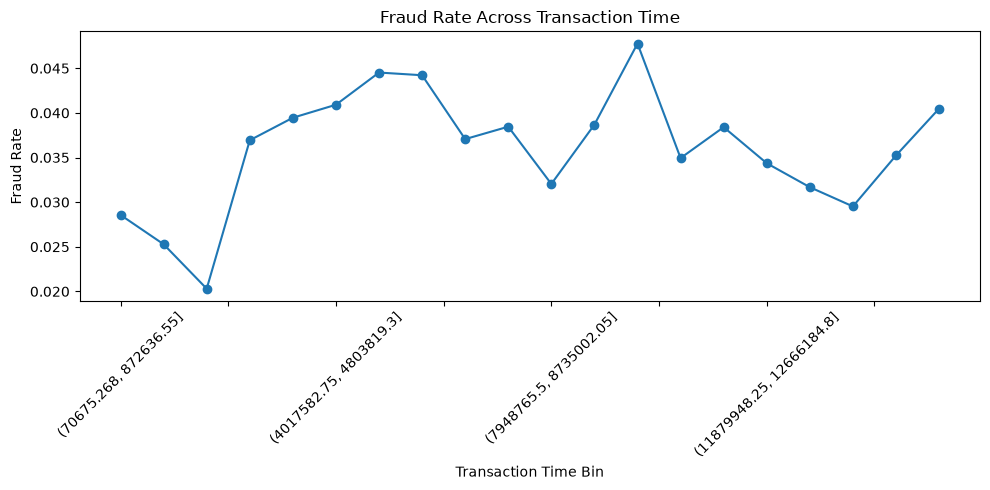


Transaction Volume by Time Bin:
                           transaction_count
time_bin                                    
(70675.268, 872636.55]                 36022
(872636.55, 1658873.1]                 40188
(1658873.1, 2445109.65]                48022
(2445109.65, 3231346.2]                31488
(3231346.2, 4017582.75]                25876
(4017582.75, 4803819.3]                26324
(4803819.3, 5590055.85]                28099
(5590055.85, 6376292.4]                27884
(6376292.4, 7162528.95]                26873
(7162528.95, 7948765.5]                29151
(7948765.5, 8735002.05]                34084
(8735002.05, 9521238.6]                26804
(9521238.6, 10307475.15]               27342
(10307475.15, 11093711.7]              29968
(11093711.7, 11879948.25]              23592
(11879948.25, 12666184.8]              24186
(12666184.8, 13452421.35]              27782
(13452421.35, 14238657.9]              26319
(14238657.9, 15024894.45]              26796
(15024894.45, 15811131

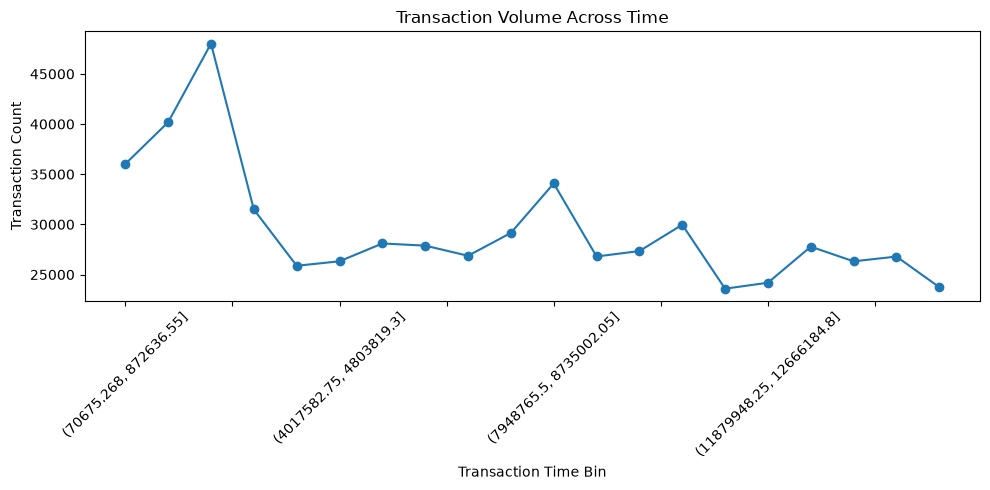


Fraud Count by Time Bin:
                           fraud_count
time_bin                              
(70675.268, 872636.55]            1029
(872636.55, 1658873.1]            1016
(1658873.1, 2445109.65]            975
(2445109.65, 3231346.2]           1163
(3231346.2, 4017582.75]           1021
(4017582.75, 4803819.3]           1077
(4803819.3, 5590055.85]           1251
(5590055.85, 6376292.4]           1233
(6376292.4, 7162528.95]            996
(7162528.95, 7948765.5]           1121
(7948765.5, 8735002.05]           1092
(8735002.05, 9521238.6]           1037
(9521238.6, 10307475.15]          1306
(10307475.15, 11093711.7]         1047
(11093711.7, 11879948.25]          906
(11879948.25, 12666184.8]          831
(12666184.8, 13452421.35]          880
(13452421.35, 14238657.9]          777
(14238657.9, 15024894.45]          944
(15024894.45, 15811131.0]          961


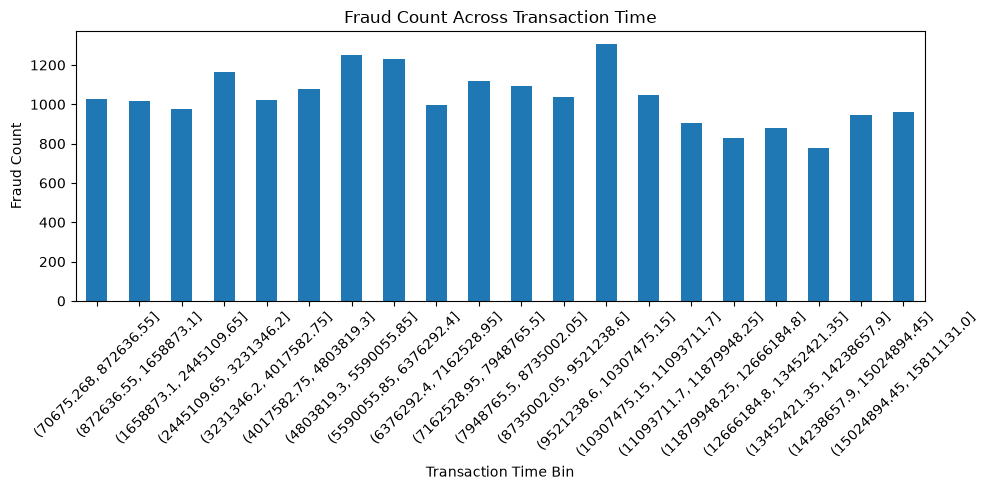


Transaction Velocity Summary:
            count       mean       std  min   25%   50%   75%   max
isFraud                                                            
0        569877.0  16.987887  8.804995  0.0  11.0  16.0  21.0  79.0
1         20663.0  15.596767  8.390227  0.0  10.0  15.0  20.0  75.0


<Figure size 800x500 with 0 Axes>

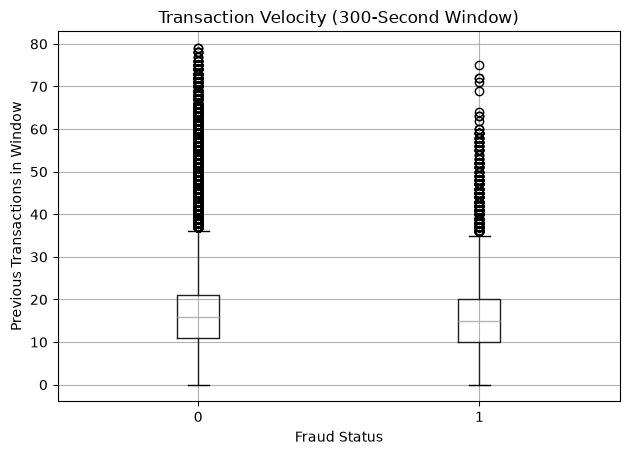


Inter-Transaction Time Summary:
            count       mean        std  min  25%   50%   75%     max
isFraud                                                              
0        569876.0  26.373462  58.456934  0.0  5.0  13.0  29.0  4138.0
1         20663.0  33.641194  78.744728  0.0  6.0  15.0  33.0  2258.0


<Figure size 800x500 with 0 Axes>

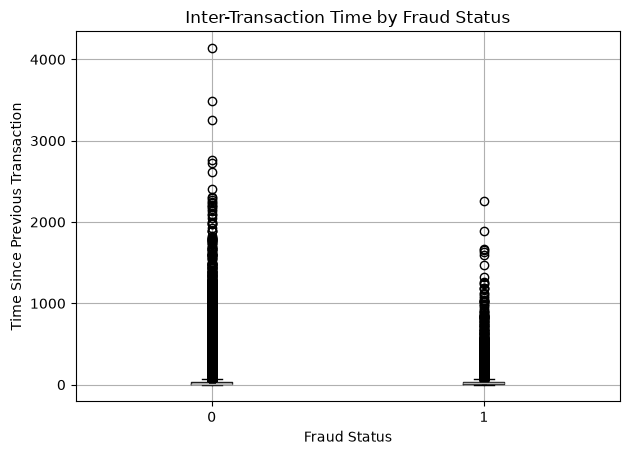

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569876.0,26.373462,58.456934,0.0,5.0,13.0,29.0,4138.0
1,20663.0,33.641194,78.744728,0.0,6.0,15.0,33.0,2258.0


In [11]:
# Fraud rate over time
temporal_analyzer = TemporalAnalyzer(FraudRateByTimeBinStrategy(bins=20))
fraud_rate_over_time = (temporal_analyzer.execute_analysis(train_transaction))
# Transaction volume
temporal_analyzer.set_strategy(TransactionVolumeByTimeBinStrategy(bins=20))
transaction_volume = (temporal_analyzer.execute_analysis(train_transaction))
# Fraud count
temporal_analyzer.set_strategy(FraudCountByTimeBinStrategy(bins=20))
fraud_count_over_time = (temporal_analyzer.execute_analysis(train_transaction))
# Transaction Velocity
velocity_analyzer = TemporalAnalyzer(TransactionVelocityStrategy(window_seconds=300))
velocity_result = (velocity_analyzer.execute_analysis(train_transaction))
velocity_result.groupby("isFraud")["transaction_velocity"].describe()
# Inter Transaction Time
inter_time_analyzer = TemporalAnalyzer(InterTransactionTimeStrategy())
inter_transaction_result = (inter_time_analyzer.execute_analysis(train_transaction))
inter_transaction_result.groupby("isFraud")["inter_transaction_time"].describe()


# Temporal Analysis Insights
--------------------------

- Fraud rate varies over time, ranging from about 2.03% to 4.78%
  compared with the overall fraud rate of about 3.50%.
- Transaction volume also changes over time, but high volume does not
  necessarily mean high fraud.
- Global 5-minute transaction velocity showed very similar distributions
  for fraud and legitimate transactions, so it is a weak standalone signal.
- Inter-transaction time showed a small difference between fraud and
  legitimate transactions, but the distributions overlap significantly.
- Conclusion: time contains useful information, but global temporal
  features alone are not sufficient for strong fraud detection.
- Further analysis should examine temporal behavior at the entity level.
- Temporal features must use only information available before or at the
  transaction time to avoid data leakage.
"""

## 6. Entity Analysis

In [12]:
# Entity based 
entity_columns = ["card1","card2","card3","card5","addr1","addr2","P_emaildomain","R_emaildomain",]
entity_analyzer = EntityAnalyzer(EntityCardinalityStrategy(entity_columns))
entity_cardinality = entity_analyzer.execute_analysis(train_transaction)
entity_cardinality


,entity,unique_entities,non_missing_transactions,shared_transaction_count,max_transactions_per_entity
0,card3,114,588975,588959,521287
1,addr2,74,524834,524816,520481
2,card5,119,586281,586264,296546
3,P_emaildomain,59,496084,496084,228355
4,R_emaildomain,60,137291,137291,57147
5,card2,500,581607,581607,48935
6,addr1,332,524834,524711,46335
7,card1,13553,590540,587096,14932


In [13]:
entity_analyzer.set_strategy(SharedEntityStrategy(entity_columns=entity_columns,min_transactions=2,top_n=20))
shared_entities = entity_analyzer.execute_analysis(train_transaction)
shared_entities.head(20)

,entity,entity_value,transaction_count
0,card3,150.0,521287
1,addr2,87.0,520481
2,card5,226.0,296546
3,P_emaildomain,gmail.com,228355
4,P_emaildomain,yahoo.com,100934
5,card5,224.0,81513
6,R_emaildomain,gmail.com,57147
7,card5,166.0,57140
8,card3,185.0,56346
9,card2,321.0,48935


In [14]:
entity_analyzer.set_strategy(EntityFraudRateStrategy(entity_columns=entity_columns,min_transactions=20,top_n=20))
entity_fraud = entity_analyzer.execute_analysis(train_transaction)
entity_fraud.head(20)

,entity,entity_value,transaction_count,fraud_count,fraud_rate
0,card1,12473,47,46,0.978723
1,card1,5853,30,23,0.766667
2,card1,9499,36,25,0.694444
3,card1,15525,28,19,0.678571
4,card1,10175,72,45,0.625000
5,card1,4347,47,29,0.617021
6,card1,5912,48,29,0.604167
7,card1,12958,25,15,0.600000
8,card1,9375,37,22,0.594595
9,card1,4693,44,26,0.590909


In [15]:
entity_analyzer.set_strategy(DeviceCardConnectivityStrategy(min_cards=2,top_n=20))
device_card_connectivity = entity_analyzer.execute_analysis(relationship_df)
device_card_connectivity

NameError: name 'relationship_df' is not defined


# Entity Analysis Insights
------------------------

- The tested entity columns have very different cardinality and sharing
  patterns.
- card1 has 13,553 unique values and provides the most granular grouping
  among the initial transaction-level candidates.
- card2 and addr1 also provide relatively granular groups and remain
  potential entity candidates.
- card3, card5, addr2, P_emaildomain and R_emaildomain have low cardinality
  and are shared by very large numbers of transactions, so they are better
  treated as categorical/context signals than individual graph entities.
- Some card1 values show very high fraud concentration, but small entity
  groups can produce unstable fraud rates, so transaction count must be
  considered with fraud rate.
- Repeated card1 + DeviceInfo relationships are present, and some pairs
  show very high observed fraud rates.
- DeviceInfo has different levels of granularity. Generic values such as
  Windows, iOS Device and MacOS are associated with thousands of card1
  values, while specific device strings are much more granular.
- Therefore, DeviceInfo should not be treated as a uniform entity field.
  Device specificity and connectivity must be considered.
- Overall, card1 is currently the strongest transaction-level entity
  candidate, while DeviceInfo is a potentially useful related entity
  after filtering overly generic values.
- These findings provide the basis for building relationship-based
  features without assuming that every repeated value represents a
  meaningful entity.


## 7. Relationship Analysis

In [ ]:
relationship_df = train_transaction.merge(train_identity,on="TransactionID",how="left")
print(relationship_df.shape)

In [ ]:
#relationship analyzing  
relationship_analyzer = RelationshipAnalyzer(
    EntityPairFrequencyStrategy("card1","DeviceInfo",top_n=20))
card_device_frequency = relationship_analyzer.execute_analysis(relationship_df)
card_device_frequency

In [ ]:
# fraud relationship
relationship_analyzer.set_strategy(
    EntityPairFraudRateStrategy("card1","DeviceInfo",min_transactions=20,top_n=20))
card_device_fraud = relationship_analyzer.execute_analysis(relationship_df)
card_device_fraud

# Relationship Analysis Insights
------------------------------

- Repeated card-device combinations are present in the transaction and
  identity data.
- Some card-device pairs occur across a large number of transactions,
  demonstrating that entity relationships can be measured directly.
- Several card-device combinations show very high observed fraud rates.
- Examples include relationships with 100% fraud across 28 and 177
  transactions, as well as approximately 97.6% fraud across 42 transactions.
- These results suggest that combinations of entities may provide stronger
  fraud signals than individual transaction attributes alone.
- However, a high-fraud pair does not by itself prove a coordinated fraud
  ring. Additional interconnected-entity analysis is required.
- DeviceInfo therefore appears to be a potentially useful entity for deeper
  relationship analysis.
"""

## 8. Multivariate Analysis

In [ ]:
multivariate_columns = ["TransactionAmt","TransactionDT","card1","card2","card3","card5","addr1","addr2",]

In [ ]:
multivariate_analyzer = MultivariateAnalyzer(CorrelationAnalysisStrategy(multivariate_columns))
correlation_result = multivariate_analyzer.execute_analysis(train_transaction)
correlation_result

In [ ]:
multivariate_analyzer.set_strategy(TargetGroupComparisonStrategy(multivariate_columns))
target_comparison = multivariate_analyzer.execute_analysis(train_transaction)
target_comparison


# Multivariate Analysis Insights
------------------------------

- Most selected numerical features show weak linear correlation with each
  other.
- TransactionAmt and TransactionDT show only weak correlation with the
  other selected variables.
- A moderate correlation was observed between card3 and addr2, but these
  fields are coded categorical/identifier-like variables, so numerical
  correlation should not be interpreted as a meaningful business
  relationship.
- Fraudulent transactions show a higher mean TransactionAmt and slightly
  higher mean TransactionDT than legitimate transactions.
- Raw means of card and address identifiers are not meaningful indicators
  because their numeric codes do not represent continuous quantities.
- Therefore, categorical and identifier features should be analyzed using
  frequency, fraud rate, association, or encoding-based methods rather than
  ordinary numerical correlation.

## 9. Final EDA Insights


# FINAL EDA INSIGHTS
============================

1. Basic Inspection
   - The transaction dataset contains 590,540 records.
   - Fraud represents approximately 3.5% of transactions.
   - The dataset contains numerical, categorical and highly sparse features.

2. Univariate Analysis
   - TransactionAmt is strongly right-skewed.
   - TransactionDT covers a broad transaction timeline.
   - ProductCD, card4 and card6 have highly uneven category distributions.

3. Bivariate Analysis
   - TransactionAmt shows a moderate difference between legitimate and fraud
     transactions.
   - Fraud rate varies across TransactionDT.
   - ProductCD and card6 show meaningful differences in fraud rate.
   - ProductCD=C has a notably higher fraud rate than the overall baseline.

4. Missing Value Analysis
   - Many D and V features have high missingness.
   - Missingness can itself be associated with fraud.
   - addr1 and addr2 missingness shows higher fraud rates.
   - Some features, such as D7 and D12-D14, show the opposite pattern.
   - Small missing groups were excluded from ranking to avoid unstable estimates.

5. Temporal Analysis
   - Fraud rate changes across the transaction timeline.
   - Transaction volume and fraud rate are not equivalent.
   - Global 5-minute transaction velocity shows weak separation.
   - Global inter-transaction time shows only a modest difference.
   - Temporal information is useful, but global timing alone is not sufficient.

6. Entity Analysis
   - Entity fields have very different cardinalities and sharing patterns.
   - card1 provides the most granular groups among the initial candidates.
   - Some card1 values show very high fraud concentration.
   - Entity frequency must be considered along with fraud rate and sample size.

7. Relationship Analysis
   - Repeated card1-DeviceInfo relationships exist.
   - Some card1-DeviceInfo pairs show very high fraud concentration.
   - This suggests that relationships between entities may provide stronger
     signals than individual transaction attributes.
   - A high-fraud relationship does not by itself prove a coordinated fraud
     ring.

8. Multivariate Analysis
   - Most selected numerical variables have weak linear correlations.
   - Identifier-like fields should not be interpreted through raw numerical
     correlation.
   - Fraud and legitimate transactions show some differences in selected
     numerical features.

FINAL CONCLUSION
----------------

The EDA identified four major signal families for TRACE:

    Transaction Signals
    Temporal Signals
    Missingness Signals
    Entity / Relationship Signals

The results suggest that TRACE should not rely on a single feature or
single fraud rule. The next stage is to convert the validated EDA findings
into leakage-safe features for the fraud-risk model.
